In [1]:
from bbq.field import Field
from bbq.polynomial import Monomial
from bbq.bbq_code import BivariateBicycle
from bbq.circuit import construct_sm_circuit, generate_noisy_circuit, simulate_x_circuit, generate_single_error_circuits, build_hx_dict, build_hz_dict, build_hx_eff, build_hz_eff, construct_decoding_matrix
from bbq.simulation import process_results
from bbq.decoder import BPOSD, BP, RelayBP

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pickle
from scipy.sparse import coo_matrix, hstack
from ldpc import BpOsdDecoder, BpDecoder


In [2]:
d = 7
field = Field(2)
x, y = Monomial(field, 'x'), Monomial(field, 'y')
a, b = 1 - x, 1 - y

bb = BivariateBicycle(a, b, d, d, 1)
hx, hz = bb.hx, bb.hz
lx, lz = bb.x_logicals, bb.z_logicals

x_order = ['idle', 0, 3, 1, 2]
z_order = [0, 3, 1, 2, 'idle']
num_cycles = d

max_iter = 300
failures_total = [5 for _ in range(10)]

circ = construct_sm_circuit(bb, x_order, z_order)


In [3]:
# All
r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])

# Qubit threshold
# r, s = 0.9, 0.013
# physical_error = np.array([s*(r**q) for q in range(10)])

# Qutrit threshold
# r, s = 0.9, 0.015
# physical_error = np.array([s*(r**q) for q in range(10)])

# New threshold
# r, s = 0.85, 0.012
# physical_error = np.array([s*(r**q) for q in range(4)])

error_rates = {'Meas': s, 'Prep': s, 'idle': s, 'CNOT': s}
hx_eff, short_hx_eff, hz_eff, short_hz_eff, s_channel_prob_x, s_channel_prob_z = construct_decoding_matrix(bb, circ, error_rates, num_cycles)


In [10]:
r, s = 0.8, 0.02
physical_error = np.array([s*(r**q) for q in range(10)])

print(f'Starting full trials over physical error rates {physical_error}')

results = []

for it, p in enumerate(physical_error):
    error_rates = {'Meas': p, 'Prep': p, 'idle': p, 'CNOT': p}
    fails = 0
    trials = 0

    if it not in [5]:
        continue

    # Generate sm circuit and decoding matrix
    channel_prob_x_tog, channel_prob_z_tog = list(2/3 * (r**it)*np.array(s_channel_prob_x)), list(2/3 * (r**it)*np.array(s_channel_prob_z))
    x_prior_tog = np.zeros((short_hx_eff.shape[1], field.p), dtype=float)
    for i, prob in enumerate(channel_prob_x_tog):
        x_prior_tog[i, 0] = 1 - prob
        for j in range(1, field.p):
            x_prior_tog[i, j] = prob / (field.p - 1)

    fail_tot = failures_total[it]

    while fails < fail_tot:
        # Generate noisy circ
        noisy_circ, err_cnt = generate_noisy_circuit(bb, circ * num_cycles, error_rates)
        
        # Simulate noisy circ
        x_syndrome_history, x_state, x_syndrome_map, x_err_count = simulate_x_circuit(bb, noisy_circ + circ + circ)

        # Calculate true logical effect
        qudits_dict = bb.qudits_dict
        data_qudits = bb.data_qudits
        x_state_data_qudits = [x_state[qudits_dict[qudit]] for qudit in data_qudits]
        x_syndrome_final_logical = (np.array(lz) @ x_state_data_qudits) % field.p
        
        # Syndrome sparsification
        z_checks = bb.Zchecks
        x_syndrome_history_copy = x_syndrome_history.copy()
        for check in z_checks:
            pos = x_syndrome_map[check]
            assert len(pos) == num_cycles + 2
            for row in range(1, num_cycles + 2):
                x_syndrome_history[pos[row]] -= x_syndrome_history_copy[pos[row-1]]
        x_syndrome_history %= field.p

        trials += 1
        # Decode
        bposd = BPOSD(field, short_hx_eff.toarray(), x_prior_tog, max_iter=max_iter)
        x_error, _ = bposd.decode(x_syndrome_history)
        assert np.all((short_hx_eff @ x_error) % field.p == x_syndrome_history)
        
        # Check logical effect
        first_logical_row = bb.l * bb.m * (num_cycles + 2)
        k = len(lx)
        x_syndrome_history_augmented_guessed = (hx_eff @ x_error) % field.p
        x_syndrome_final_logical_guessed = x_syndrome_history_augmented_guessed[first_logical_row: first_logical_row + k]
        
        if not np.array_equal(x_syndrome_final_logical_guessed, x_syndrome_final_logical):
            fails += 1
            print(f'Physical error rate: {p:.4f}, Trial: {trials}, Failures: {fails}')

        if trials % 20 == 0:
            print(f'UPDATE: Physical error rate: {p:.4f}, Trial: {trials}, Failures: {fails}')
    print('--------------------------------------------------------------')
    results.append(trials)


Starting full trials over physical error rates [0.02       0.016      0.0128     0.01024    0.008192   0.0065536
 0.00524288 0.0041943  0.00335544 0.00268435]
Physical error rate: 0.0066, Trial: 8, Failures: 1
UPDATE: Physical error rate: 0.0066, Trial: 20, Failures: 1
UPDATE: Physical error rate: 0.0066, Trial: 40, Failures: 1
UPDATE: Physical error rate: 0.0066, Trial: 60, Failures: 1
Physical error rate: 0.0066, Trial: 71, Failures: 2
Physical error rate: 0.0066, Trial: 76, Failures: 3
UPDATE: Physical error rate: 0.0066, Trial: 80, Failures: 3
Physical error rate: 0.0066, Trial: 87, Failures: 4
Physical error rate: 0.0066, Trial: 99, Failures: 5
--------------------------------------------------------------


In [ ]:
results


[64]

## Let's gooo

In [76]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pickle


In [12]:
save_data_files = []

# save_data_files.append(json.load(open('../scripts/metric_3x3_qubit_bpm_long.json', 'r')))
# save_data_files.append(json.load(open('../scripts/metric_3x3_qutrit_bpm_long.json', 'r')))
# save_data_files.append(json.load(open('../scripts/metric_3x3_ququint_bpm_long.json', 'r')))
# save_data_files.append(json.load(open('../scripts/metric_3x3_quhendecabit_bpm_long.json', 'r')))

save_data_files.append(json.load(open('../scripts/metric_5x5_qubit_bpm_long.json', 'r')))
save_data_files.append(json.load(open('../scripts/metric_5x5_qutrit_bpm_long.json', 'r')))
save_data_files.append(json.load(open('../scripts/metric_5x5_ququint_bpm_long.json', 'r')))
save_data_files.append(json.load(open('../scripts/metric_5x5_quhendecabit_bpm_long.json', 'r')))


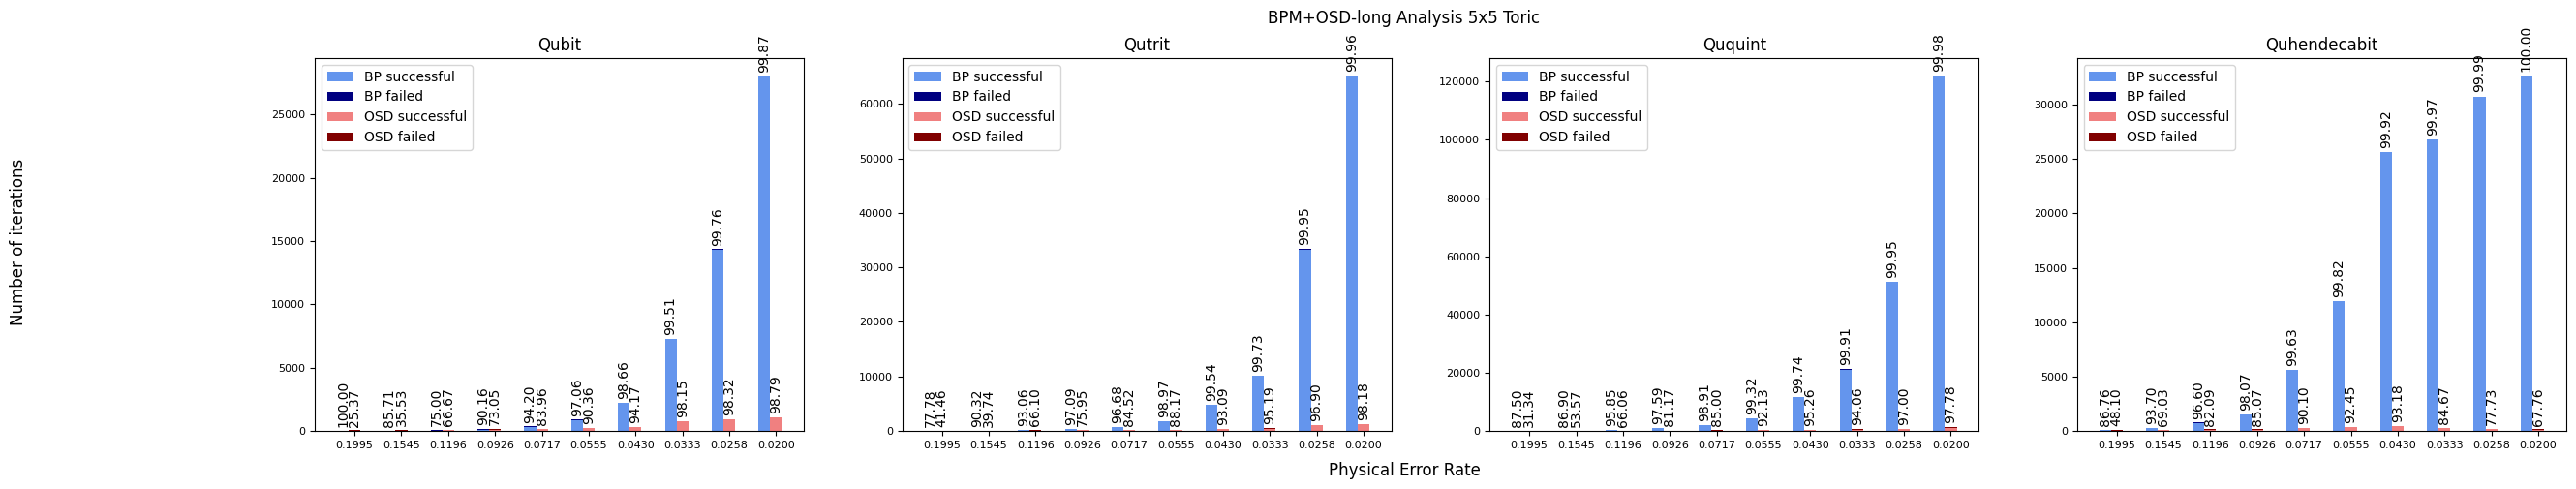

In [13]:
c = len(save_data_files)
fig, axes = plt.subplots(nrows=1, ncols=c, figsize=(30, 5))

for col in range(c):
        save_data = save_data_files[col]
        qec_code_name = save_data['qec_code_name']
        num_failures = save_data['num_failures']
        error_rates = save_data['error_rates']
        results = np.array(save_data['results'])
        only_bp = np.array(save_data['only_bp'])
        bp_fail = np.array(save_data['bp_fail'])
        osd_fail = np.array(save_data['osd_fail'])

        ax = axes[col]

        physical_error_rate = [f'{p:.4f}' for p in error_rates]
        data = [[['BP successful', 'BP failed'], [only_bp - bp_fail, bp_fail]],
                [['OSD successful', 'OSD failed'], [results - only_bp - osd_fail, osd_fail]]]

        x = np.arange(10)
        width = 0.25
        multiplier = 0

        offset = width * multiplier
        rects = ax.bar(x + offset, only_bp - bp_fail, width, label='BP successful', color='cornflowerblue')
        ax.bar(x + offset, bp_fail, width, bottom=only_bp - bp_fail, label='BP failed', color='navy')
        ax.bar_label(rects, labels= [f'{(p*100):.2f}' for p in (only_bp - bp_fail) / only_bp], padding=3, rotation=90)

        multiplier += 1
        offset = width * multiplier
        rects = ax.bar(x + offset, results - only_bp - osd_fail, width, label='OSD successful', color='lightcoral')
        ax.bar(x + offset, osd_fail, width, bottom=results - only_bp - osd_fail, label='OSD failed', color='maroon')
        ax.bar_label(rects, labels= [f'{(p*100):.2f}' for p in (results - only_bp - osd_fail) / (results - only_bp)], padding=3, rotation=90)

        ax.set_title(qec_code_name)
        ax.set_xticks(x + width, physical_error_rate)
        ax.legend(loc='upper left')

        ax.tick_params(labelsize=8)

fig.supxlabel('Physical Error Rate')
fig.supylabel('Number of iterations')
fig.suptitle('BPM+OSD-long Analysis 5x5 Toric')

plt.show();


## Binary OSD

In [ ]:
field = Field(3)
bin_array = np.array([0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])


In [ ]:
qudits = bin_array.shape[0] // (field.p-1)

array = np.zeros(qudits, dtype=int)
zeros = np.nonzero(bin_array)[0]

for z in zeros:
    array[z // (field.p-1)] = z % (field.p-1) + 1


In [ ]:
array


array([0, 2, 1, 1, 0, 1, 2])

## Old Plots

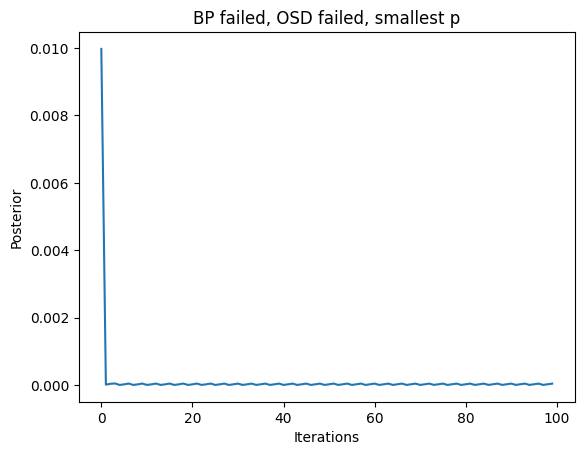

In [32]:
d=100

y = np.array(posteriors[9][3])[:, :, 1]
x = np.arange(0, len(y))

# for qubit in range(y.shape[1]):
#     plt.plot(x[0:d], y[:, qubit][0:d])

plt.plot(x[0:d], y[:, 3][0:d])

plt.xlabel('Iterations')
plt.ylabel('Posterior')
plt.title('BP failed, OSD failed, smallest p');


In [73]:
save_data = json.load(open('../scripts/relay_5x5_qubit.json', 'r'))
qec_code_name = save_data['qec_code_name']
noise_model = save_data['noise_model']
num_failures = save_data['num_failures']
error_rates = save_data['error_rates']
results = np.array(save_data['results'])
only_bp = np.array(save_data['only_bp'])
bp_fail = np.array(save_data['bp_fail'])
osd_fail = np.array(save_data['osd_fail'])
weights = save_data['weights']

with open('../scripts/relay_5x5_qubit', 'rb') as handle:
    posteriors = pickle.load(handle)


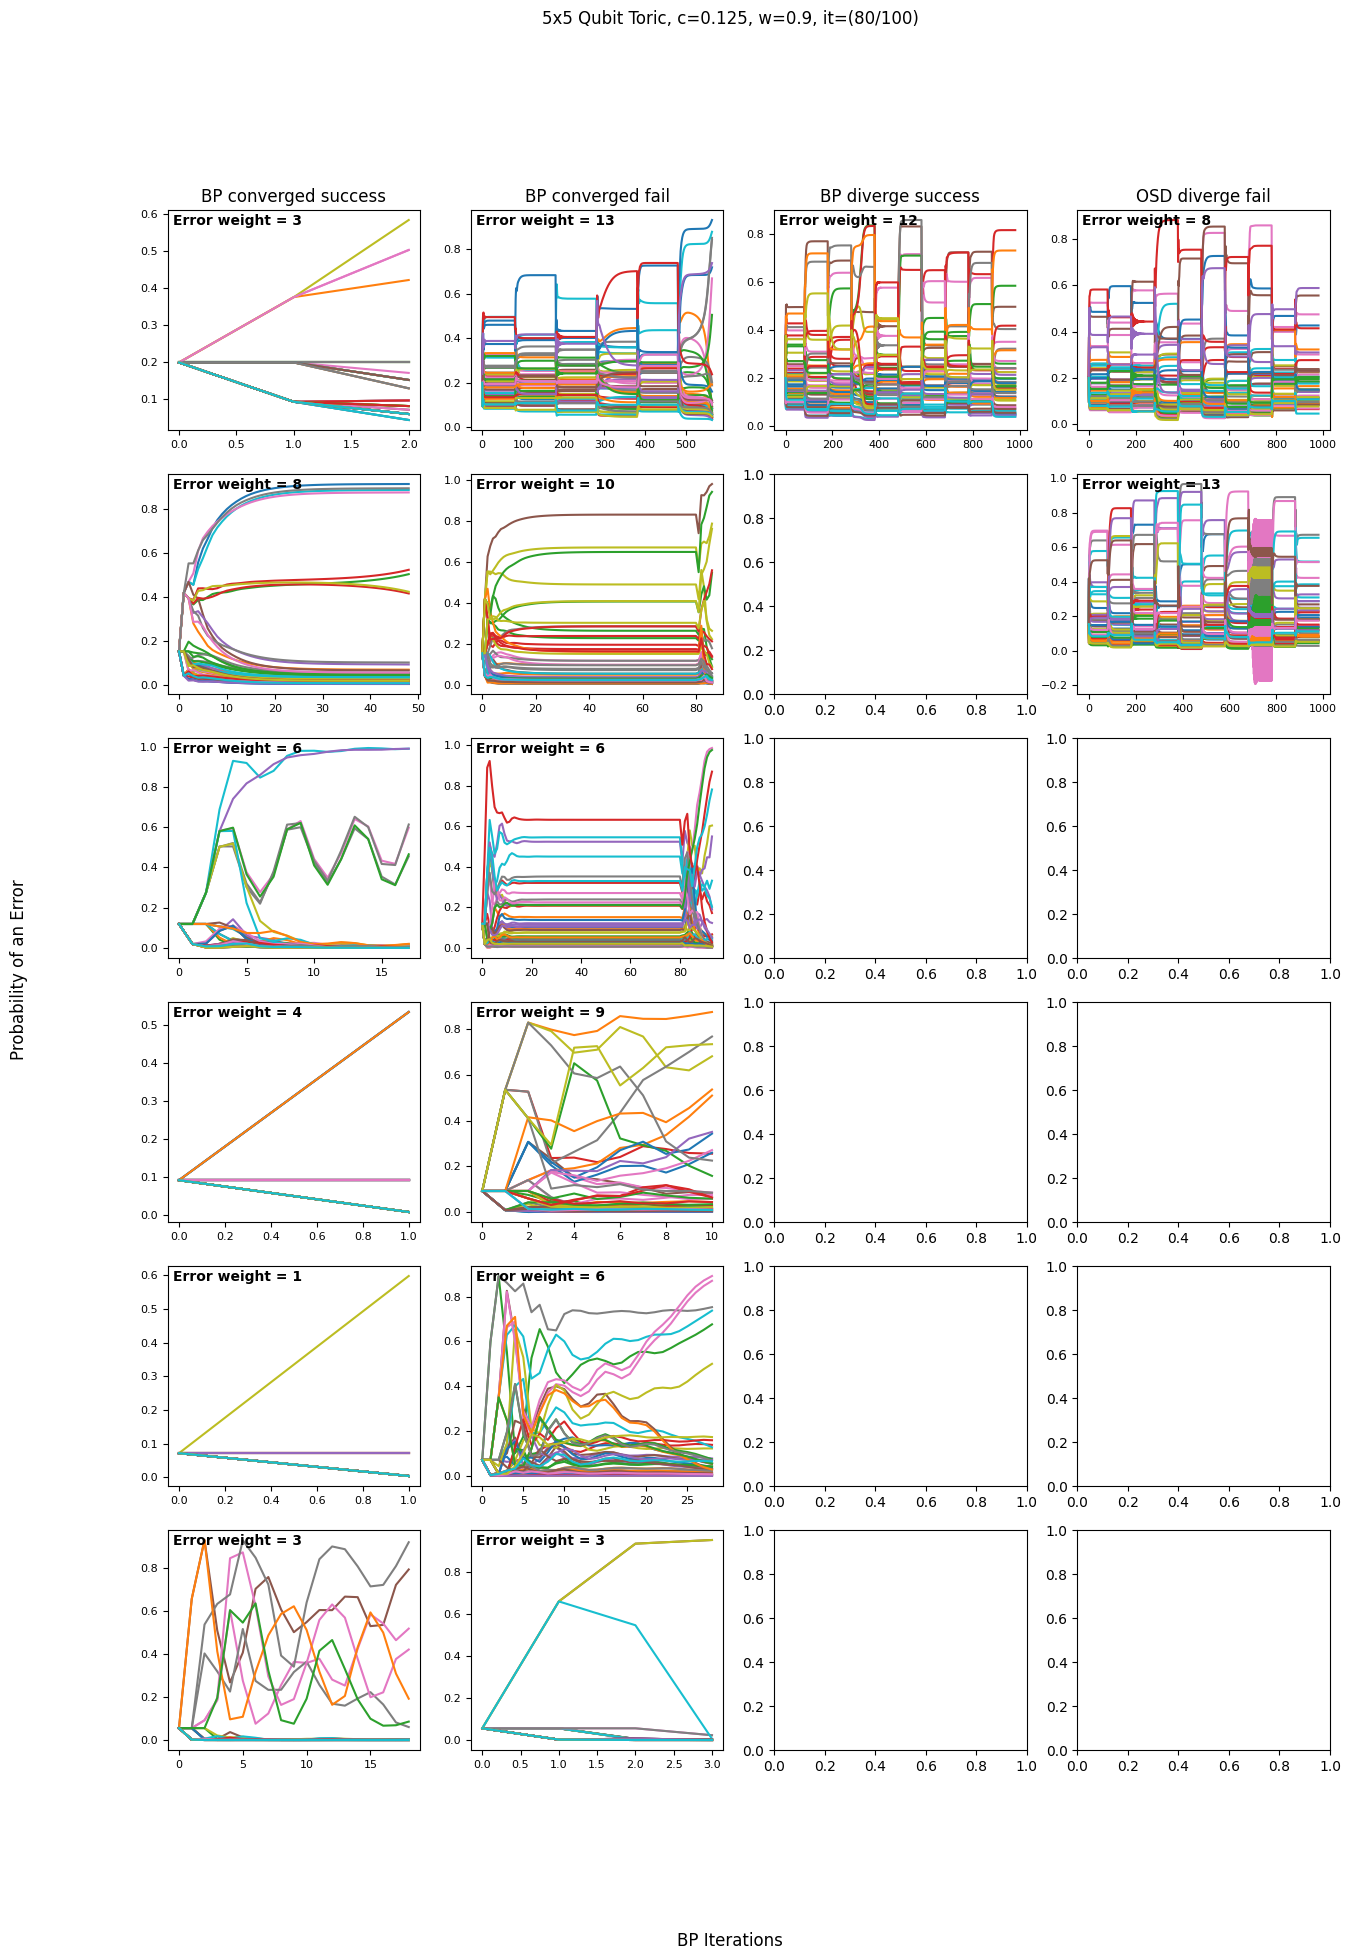

In [75]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(15, 20))

for row in range(6):
    for col in range(4):
        ax = axes[row, col]
        if (row==0) and (col==0):
            ax.set_title('BP converged success')
        if (row==0) and (col==1):
            ax.set_title('BP converged fail')
        if (row==0) and (col==2):
            ax.set_title('BP diverge success')
        if (row==0) and (col==3):
            ax.set_title('OSD diverge fail')

        if not posteriors[row][col]:
            continue

        y = np.array(posteriors[row][col])[:, :, 1]
        x = np.arange(0, len(y))

        for qubit in range(y.shape[1]):
            ax.plot(x, y[:, qubit])
        ax.tick_params(labelsize=8)

        ax.text(0.02, 0.98, f'Error weight = {weights[row][col]}', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

fig.supxlabel('BP Iterations')
fig.supylabel('Probability of an Error')
fig.suptitle('5x5 Qubit Toric, c=0.125, w=0.9, it=(80/100)')

plt.show();


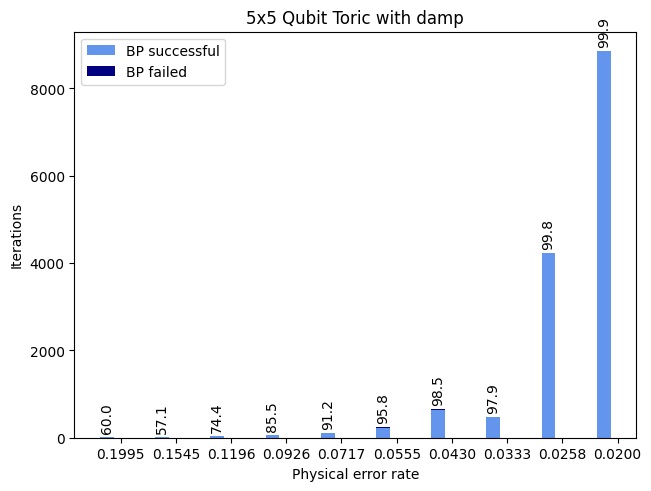

In [71]:
physical_error_rate = [f'{p:.4f}' for p in error_rates]
data = [[['BP successful', 'BP failed'], [only_bp - bp_fail, bp_fail]],
        [['OSD successful', 'OSD failed'], [results - only_bp - osd_fail, osd_fail]]]

x = np.arange(10)
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

offset = width * multiplier
rects = ax.bar(x + offset, only_bp - bp_fail, width, label='BP successful', color='cornflowerblue')
ax.bar(x + offset, bp_fail, width, bottom=only_bp - bp_fail, label='BP failed', color='navy')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (only_bp - bp_fail) / only_bp], padding=3, rotation=90)

# multiplier += 1
# offset = width * multiplier
# rects = ax.bar(x + offset, results - only_bp - osd_fail, width, label='LSDbin successful', color='lightcoral')
# ax.bar(x + offset, osd_fail, width, bottom=results - only_bp - osd_fail, label='LSDbin failed', color='maroon')
# ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (results - only_bp - osd_fail) / (results - only_bp)], padding=3, rotation=90)

ax.set_ylabel('Iterations')
ax.set_xlabel('Physical error rate')
ax.set_title('5x5 Qubit Toric with damp')
ax.set_xticks(x + width, physical_error_rate)
ax.legend(loc='upper left')

plt.show()


In [7]:
save_data = json.load(open('../scripts/metric_3x3_qutrit_bpm_long.json', 'r'))
qec_code_name = save_data['qec_code_name']
noise_model = save_data['noise_model']
num_failures = save_data['num_failures']
error_rates = save_data['error_rates']
results = np.array(save_data['results'])
only_bp = np.array(save_data['only_bp'])
bp_fail = np.array(save_data['bp_fail'])
osd_fail = np.array(save_data['osd_fail'])
weights = save_data['weights']

with open('../scripts/metric_3x3_qutrit_bpm_long_post', 'rb') as handle:
    posteriors = pickle.load(handle)


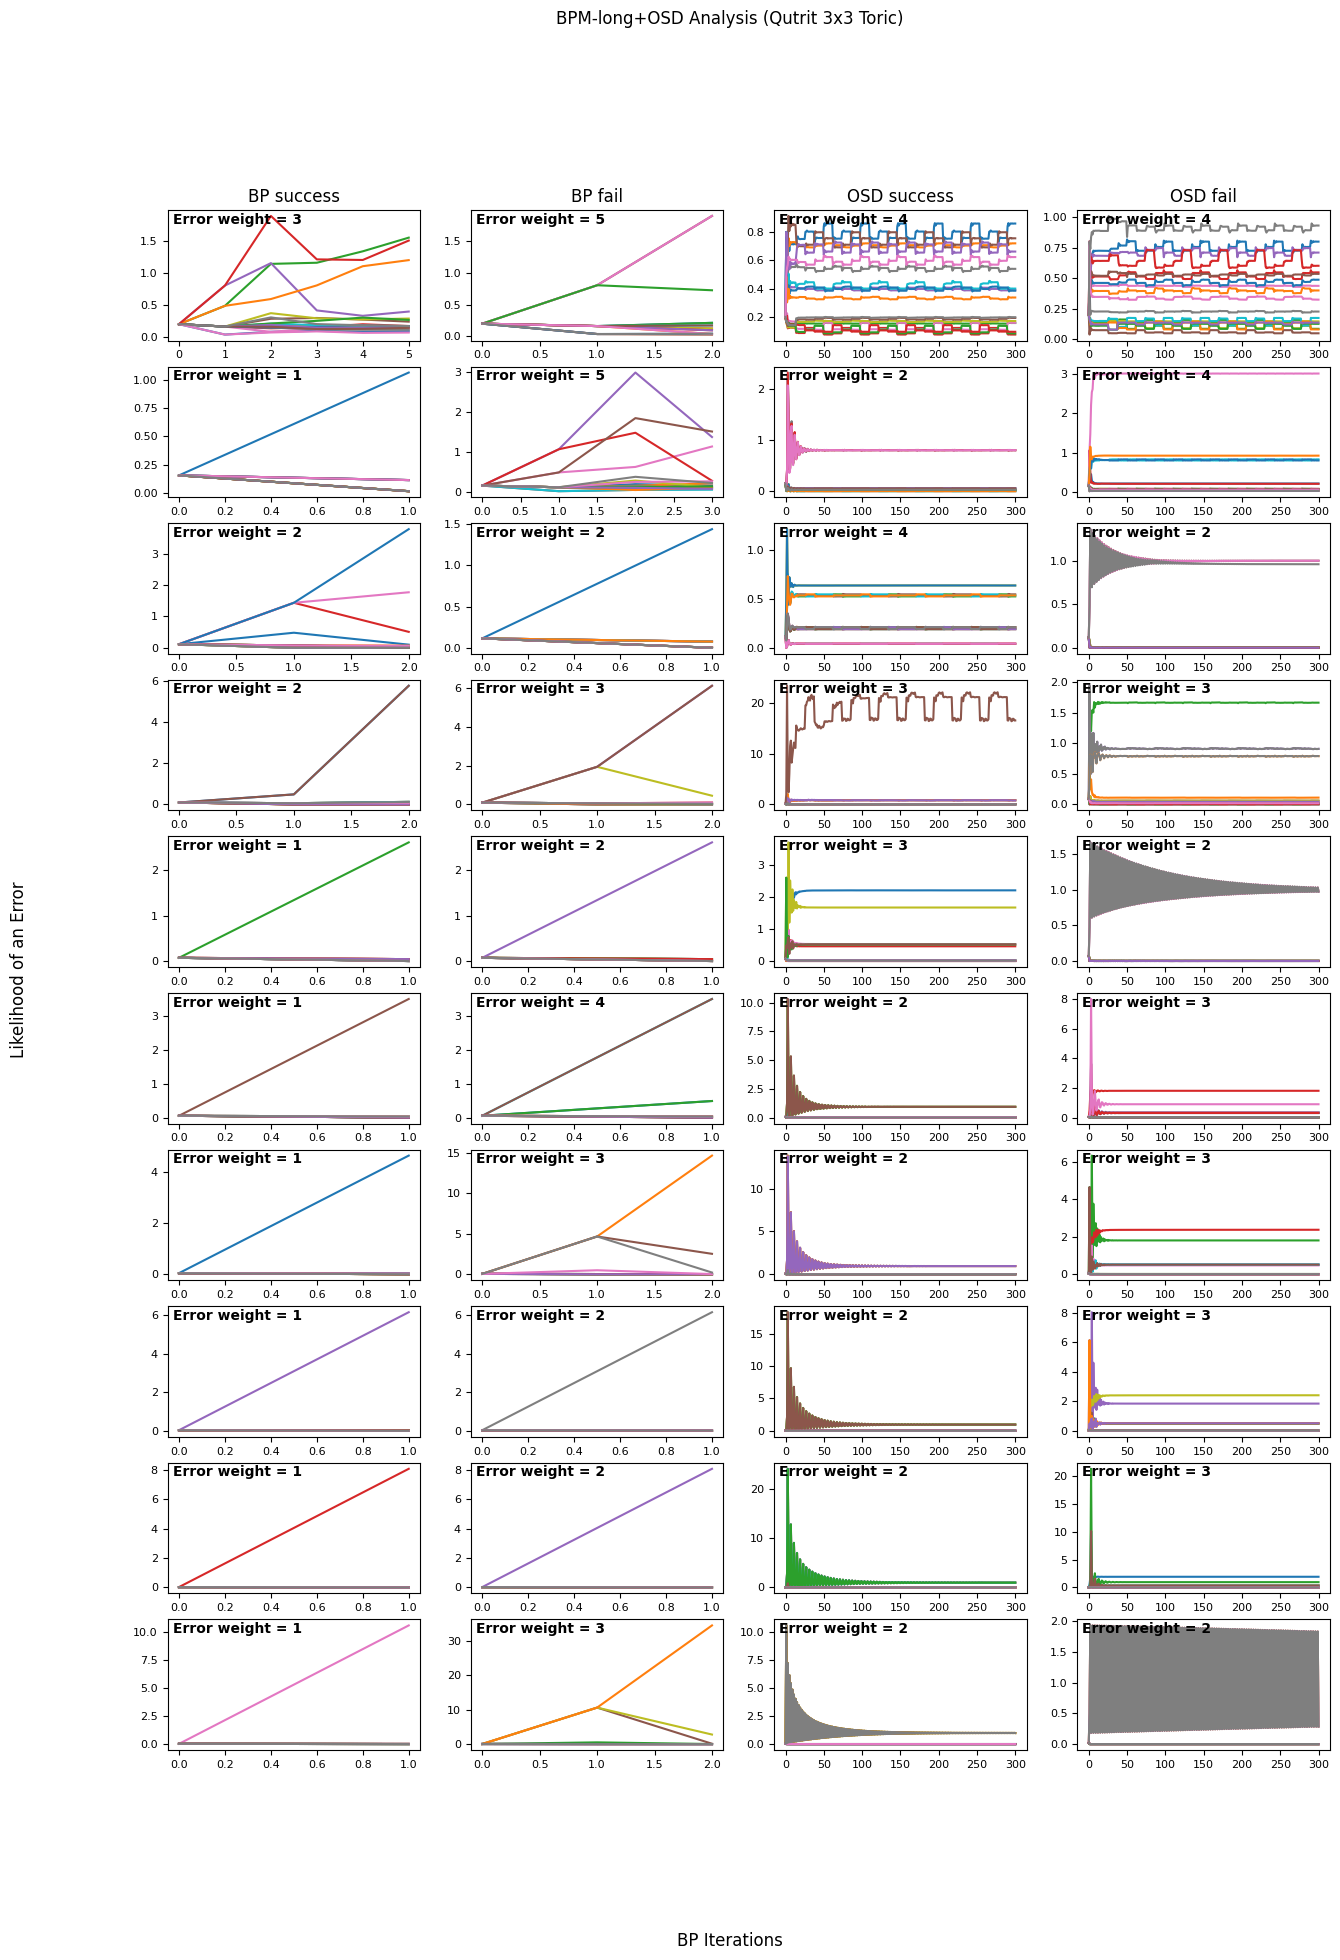

In [11]:
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(15, 20))

for row in range(10):
    for col in range(4):
        ax = axes[row, col]
        y = np.array(posteriors[row][col])[:, :, 1] + np.array(posteriors[row][col])[:, :, 2]
        x = np.arange(0, len(y))

        for qubit in range(y.shape[1]):
            ax.plot(x, y[:, qubit])
        ax.tick_params(labelsize=8)

        if (row==0) and (col==0):
            ax.set_title('BP success')
        if (row==0) and (col==1):
            ax.set_title('BP fail')
        if (row==0) and (col==2):
            ax.set_title('OSD success')
        if (row==0) and (col==3):
            ax.set_title('OSD fail')

        ax.text(0.02, 0.98, f'Error weight = {weights[row][col]}', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

fig.supxlabel('BP Iterations')
fig.supylabel('Likelihood of an Error')
fig.suptitle('BPM-long+OSD Analysis (Qutrit 3x3 Toric)')

plt.show();


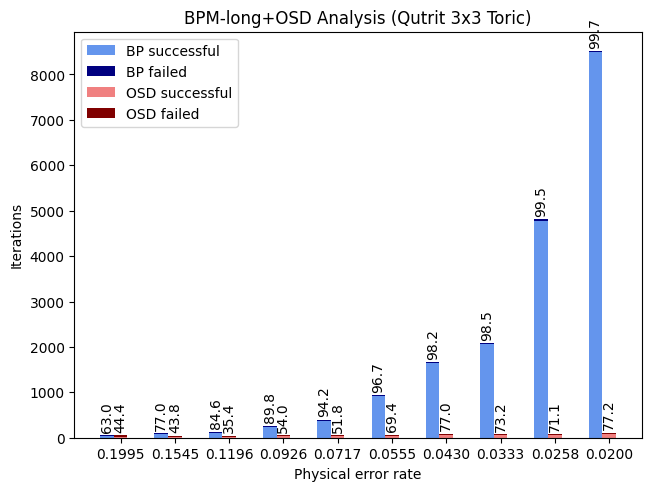

In [10]:
physical_error_rate = [f'{p:.4f}' for p in error_rates]
data = [[['BP successful', 'BP failed'], [only_bp - bp_fail, bp_fail]],
        [['OSD successful', 'OSD failed'], [results - only_bp - osd_fail, osd_fail]]]

x = np.arange(10)
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

offset = width * multiplier
rects = ax.bar(x + offset, only_bp - bp_fail, width, label='BP successful', color='cornflowerblue')
ax.bar(x + offset, bp_fail, width, bottom=only_bp - bp_fail, label='BP failed', color='navy')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (only_bp - bp_fail) / only_bp], padding=3, rotation=90)

multiplier += 1
offset = width * multiplier
rects = ax.bar(x + offset, results - only_bp - osd_fail, width, label='OSD successful', color='lightcoral')
ax.bar(x + offset, osd_fail, width, bottom=results - only_bp - osd_fail, label='OSD failed', color='maroon')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (results - only_bp - osd_fail) / (results - only_bp)], padding=3, rotation=90)

ax.set_ylabel('Iterations')
ax.set_xlabel('Physical error rate')
ax.set_title('BPM-long+OSD Analysis (Qutrit 3x3 Toric)')
ax.set_xticks(x + width, physical_error_rate)
ax.legend(loc='upper left')

plt.show()


In [ ]:
save_data = json.load(open('../scripts/metric_3x3_ququint.json', 'r'))
qec_code_name = save_data['qec_code_name']
noise_model = save_data['noise_model']
num_failures = save_data['num_failures']
error_rates = save_data['error_rates']
results = np.array(save_data['results'])
only_bp = np.array(save_data['only_bp'])
bp_fail = np.array(save_data['bp_fail'])
osd_fail = np.array(save_data['osd_fail'])
weights = save_data['weights']

with open('../scripts/metric_3x3_ququint_post', 'rb') as handle:
    posteriors = pickle.load(handle)


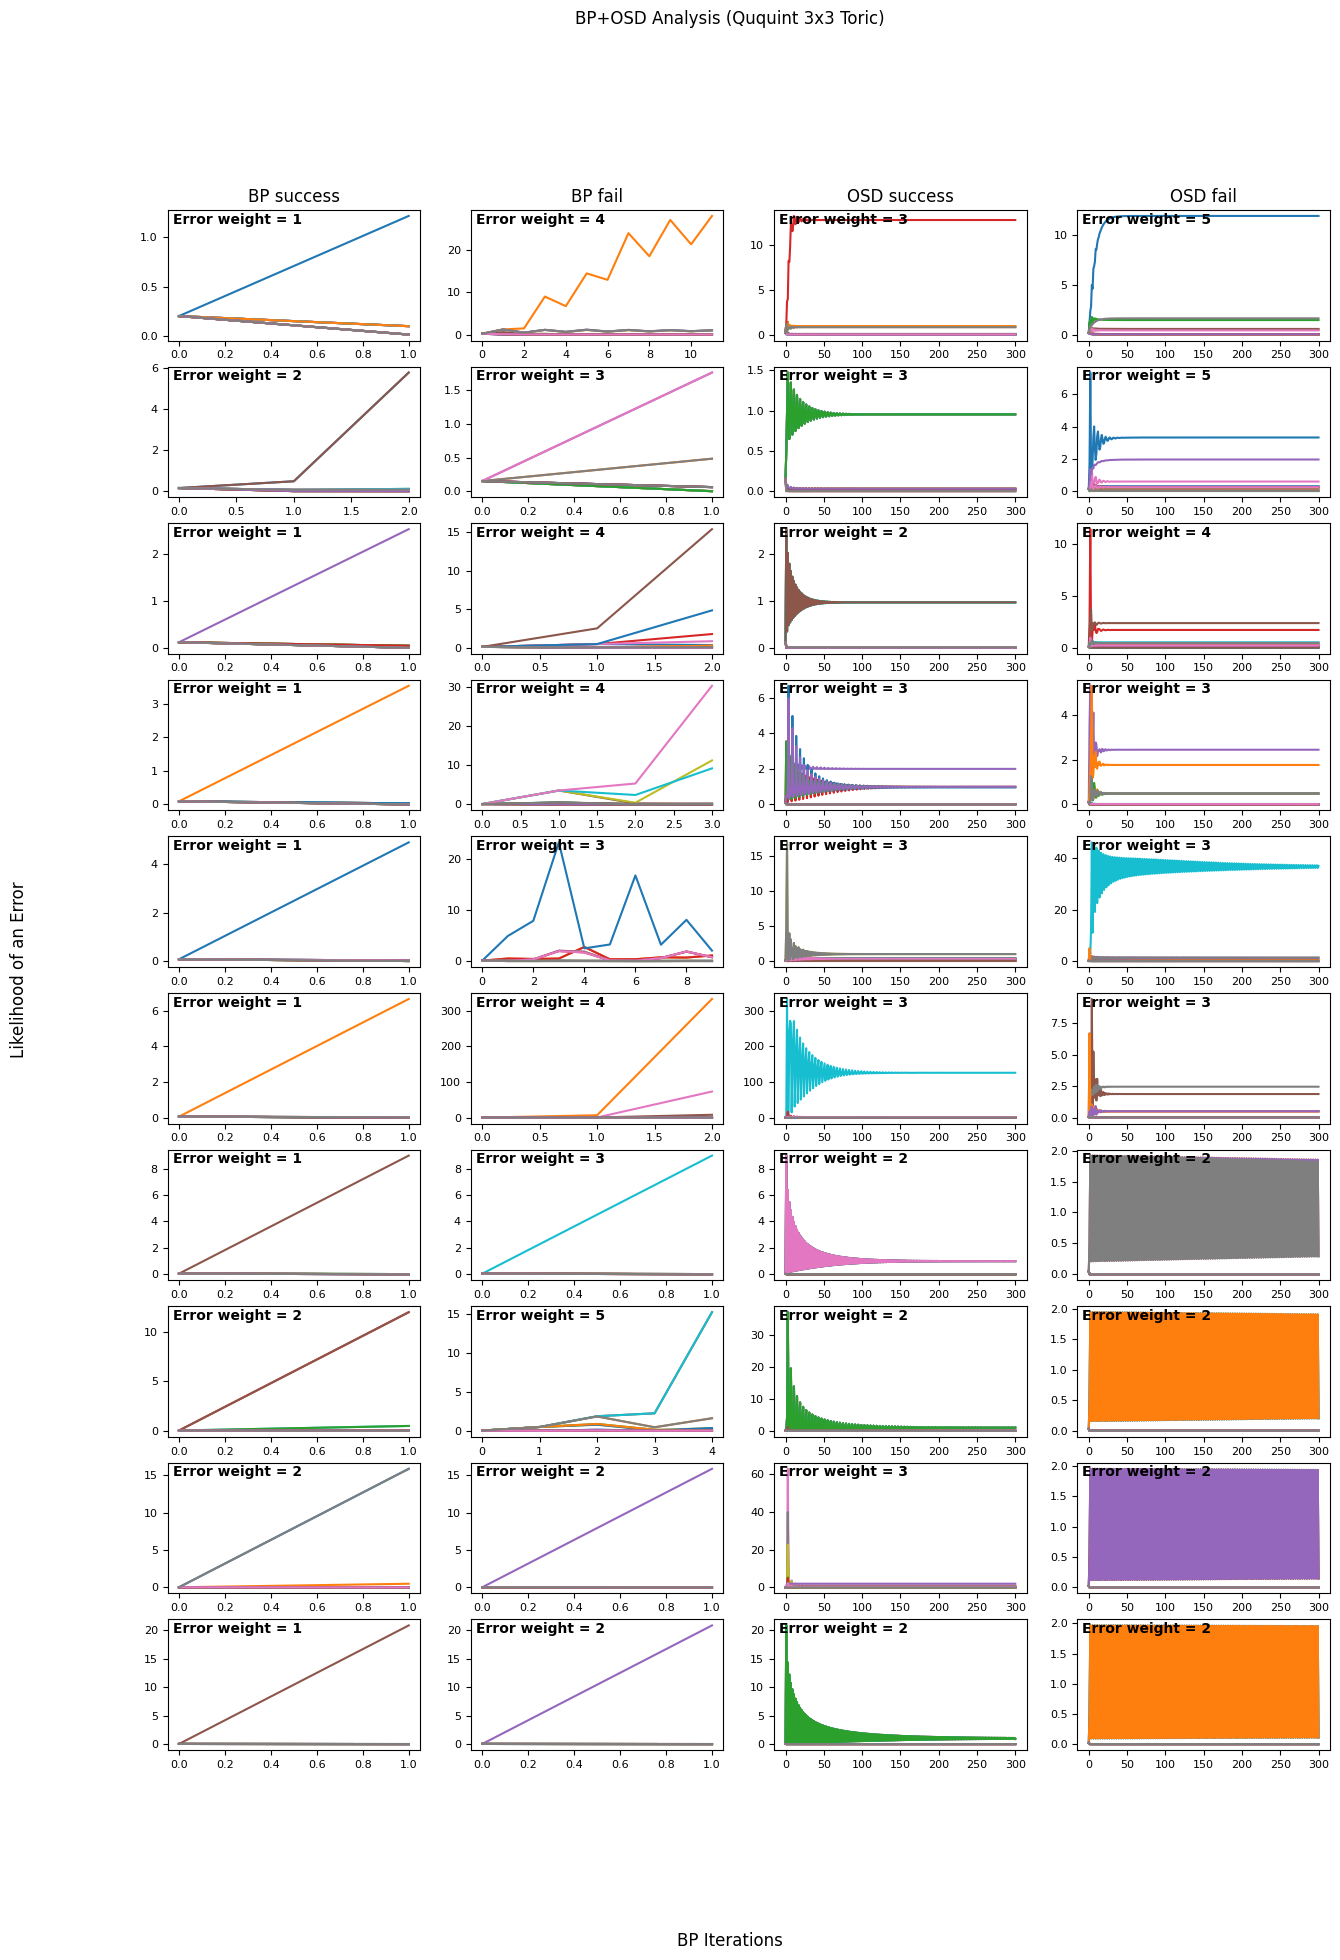

In [ ]:
fig, axes = plt.subplots(nrows=10, ncols=4, figsize=(15, 20))

for row in range(10):
    for col in range(4):
        ax = axes[row, col]
        y = np.array(posteriors[row][col])[:, :, 1] + np.array(posteriors[row][col])[:, :, 2] + np.array(posteriors[row][col])[:, :, 3] + np.array(posteriors[row][col])[:, :, 4]
        x = np.arange(0, len(y))

        for qubit in range(y.shape[1]):
            ax.plot(x, y[:, qubit])
        ax.tick_params(labelsize=8)

        if (row==0) and (col==0):
            ax.set_title('BP success')
        if (row==0) and (col==1):
            ax.set_title('BP fail')
        if (row==0) and (col==2):
            ax.set_title('OSD success')
        if (row==0) and (col==3):
            ax.set_title('OSD fail')

        ax.text(0.02, 0.98, f'Error weight = {weights[row][col]}', transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

fig.supxlabel('BP Iterations')
fig.supylabel('Likelihood of an Error')
fig.suptitle('BP+OSD Analysis (Ququint 3x3 Toric)')

plt.show();


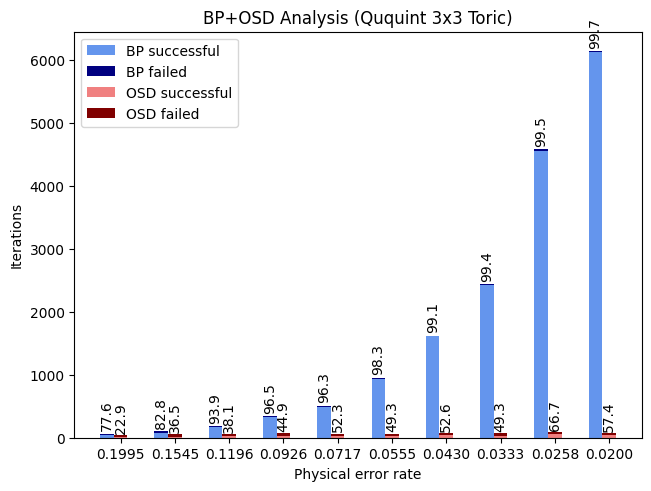

In [ ]:
physical_error_rate = [f'{p:.4f}' for p in error_rates]
data = [[['BP successful', 'BP failed'], [only_bp - bp_fail, bp_fail]],
        [['OSD successful', 'OSD failed'], [results - only_bp - osd_fail, osd_fail]]]

x = np.arange(10)
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

offset = width * multiplier
rects = ax.bar(x + offset, only_bp - bp_fail, width, label='BP successful', color='cornflowerblue')
ax.bar(x + offset, bp_fail, width, bottom=only_bp - bp_fail, label='BP failed', color='navy')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (only_bp - bp_fail) / only_bp], padding=3, rotation=90)

multiplier += 1
offset = width * multiplier
rects = ax.bar(x + offset, results - only_bp - osd_fail, width, label='OSD successful', color='lightcoral')
ax.bar(x + offset, osd_fail, width, bottom=results - only_bp - osd_fail, label='OSD failed', color='maroon')
ax.bar_label(rects, labels= [f'{(p*100):.1f}' for p in (results - only_bp - osd_fail) / (results - only_bp)], padding=3, rotation=90)

ax.set_ylabel('Iterations')
ax.set_xlabel('Physical error rate')
ax.set_title('BP+OSD Analysis (Ququint 3x3 Toric)')
ax.set_xticks(x + width, physical_error_rate)
ax.legend(loc='upper left')

plt.show()
